In [58]:
from atomica.models import MultiClassClassifierModel, MultiLabelClassifierModel, ResidueClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset, LabelledPDBDataset
from atomica.trainers import Trainer

from multiclass_metrics import compute_multiclass_metrics
from multilabel_metrics import compute_multilabel_metrics
from atomica_rna_mlp import compute_binary_metrics

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from glob import glob

sns.set_context("notebook")
custom_colors = ['#E0B8E0', '#C8A0C8', '#B088B0', '#987098', '#806080', '#00C4C7', '#059094']
xtick_map = {
    'RNAGlib': 'RNAGlib',
    'grnade': 'gRNAde',
    'rinalmo': 'RiNALMo',
    'rnafm': 'RNA-FM',
    'rnaernie': 'RNAErnie',
    'atomica': 'ATOMICA',
    'atomica-ensemble': 'ATOMICA\nEnsemble',
    'grnade (ensemble)': 'gRNAde\nEnsemble',
    'rinalmo (ensemble)': 'RiNALMo\nEnsemble',
    'rnaernie (ensemble)': 'RNAErnie\nEnsemble',
    'rnafm (ensemble)': 'RNA-FM\nEnsemble',
}

DATA_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks"
MODEL_DIR="/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark"
SAVED_MODEL_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks/models/atomica"

In [73]:
def process_atomica_rnafm_mlp_results(results_dir: str, val_metric: str) -> pd.DataFrame:
    results = []
    for version in os.listdir(results_dir):
        if not version.startswith("version_"):
            continue
        for seed in os.listdir(os.path.join(results_dir, version)):
            if not seed.startswith("seed_"):
                continue
            if not os.path.exists(os.path.join(results_dir, version, seed, "training_history.json")):
                continue
            with open(os.path.join(results_dir, version, seed, "training_history.json"), "r") as f:
                training_history = json.load(f)
            val_metric_value = training_history[val_metric]
            results.append({
                "version": version,
                "seed": seed,
                "val_metric": val_metric_value,
            })
    df = pd.DataFrame(results)
    ave_df = df.groupby('version')[['val_metric']].mean()
    ave_df.sort_values(by='val_metric', ascending=False, inplace=True)
    
    test_results = []
    best_version = ave_df.index[0]
    ensemble_probs = []
    for seed in os.listdir(os.path.join(results_dir, best_version)):
        test_metrics_path = os.path.join(results_dir, best_version, seed, "test_metrics.json")
        test_probs = np.load(os.path.join(results_dir, best_version, seed, "test_probabilities.npy"))
        ensemble_probs.append(test_probs)
        # print("Reading test metrics from", test_metrics_path)
        with open(test_metrics_path, "r") as f:
            test_metrics = json.load(f)
        test_metrics['version'] = best_version
        test_metrics['seed'] = seed
        test_metrics['checkpoint_path'] = os.path.join(results_dir, best_version, seed)
        test_results.append(test_metrics)
    ensemble_probs = np.mean(np.stack(ensemble_probs), axis=0)
    task_name = os.path.basename(results_dir)
    model_name = os.path.basename(os.path.dirname(results_dir))
    test_true = np.load(f"{DATA_DIR}/{task_name}/{task_name}_test_labels_{model_name}.npy")
    print("Test True", test_true.shape)
    if task_name == "RNA_Ligand":
        preds = np.argmax(ensemble_probs, axis=1)
        print("Test Preds", preds.shape)
        test_metrics = compute_multiclass_metrics(test_true, preds, y_proba=ensemble_probs)
    elif task_name == "RNAGo":
        preds = ensemble_probs >= 0.5
        print("Test Preds", preds.shape)
        test_metrics = compute_multilabel_metrics(test_true, preds, y_proba=ensemble_probs)
    else:
        preds = ensemble_probs[:, 1] >= 0.5
        print("Test Preds", preds.shape)
        test_metrics = compute_binary_metrics(
            test_true, y_pred=preds, y_proba=ensemble_probs
        )
    test_metrics = test_metrics.to_dict()
    test_metrics['version'] = 'ensemble'
    test_metrics['seed'] = 'ensemble'
    test_metrics['checkpoint_path'] = 'ensemble'
    test_results.append(test_metrics)
    return pd.DataFrame(test_results)

def get_model(model_checkpoint: str, task_name: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    if task_name == "RNAGo":
        return MultiLabelClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Ligand":
        return MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Protein" or task_name == "RNA_Site":
        return ResidueClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    else:
        raise ValueError(f"Task name {task_name} not supported")

def get_atomica_results(model_checkpoint, task_name, split="val", threshold=0.5, recompute=False):
    if not recompute and os.path.exists(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet")):
        results = pd.read_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
        if 'ckpt' in results.columns and model_checkpoint in results['ckpt'].tolist():
            return results
    dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed_RNA.parquet")
    model = get_model(model_checkpoint, task_name)

    model.eval()
    model.to("cuda")
    batch_size = 1

    atomica_preds_run = []
    for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc="Running inference"):
        with torch.no_grad():
            batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
            batch = MultiClassLabelledPDBDataset.collate_fn(batch)
            batch = Trainer.to_device(batch, "cuda")
            atomica_preds_run.append(model.infer(batch).cpu().numpy())
    atomica_preds = np.concatenate(atomica_preds_run)
    
    if task_name == "RNA_Protein":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_ids = sum([[x['id']] * len(x['label']) for x in dataset.data], [])
        atomica_preds = atomica_preds.flatten()
    elif task_name == "RNA_Site":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_preds = atomica_preds.flatten()
        atomica_ids = []
        for x in dataset.data:
            assert len(x['label']) == len(x['block_to_pdb_indexes'])
            for _, pdb_index in sorted(x['block_to_pdb_indexes'].items()):
                atomica_ids.append(x['id'] + '_' + str(pdb_index))
    else:
        atomica_labels = np.array([x['label'] for x in dataset.data])
        atomica_ids = np.array([x['id'] for x in dataset.data])
        atomica_labels = list(atomica_labels)
        atomica_preds = list(atomica_preds)
    atomica_results = pd.DataFrame({
        'id': atomica_ids,
        'label': atomica_labels,
        'pred_probability': atomica_preds,
    })
    if task_name == "RNA_Ligand":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: np.argmax(x))
    elif task_name == "RNAGo":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: (x > threshold).astype(int))
    else:
        atomica_results['pred'] = (atomica_results['pred_probability'] > threshold).astype(int)

    atomica_results.to_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    return atomica_results

In [ ]:
def load_rnaglib_baseline(fname):
    with open(fname, "r") as f:
        lines = f.readlines()
    lines = [line.strip()[len("Test metrics: "):] for line in lines if line.startswith("Test metrics: ")]
    metrics = [ast.literal_eval(line) for line in lines]
    return pd.DataFrame(metrics)

rnaglib_baselines = {}
for i, task_name in enumerate(["RNA_Ligand","RNA_Site","RNA_Protein","RNAGo"]):
    fname = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/job_status/train_rnaglib_baselines.*.54939697_{i}.out")
    df = load_rnaglib_baseline(fname[0])
    df['baseline_model'] = 'RNAGlib'
    agg_method = {col: ['mean', 'std'] for col in df.columns if col != 'baseline_model'}
    df = df.groupby('baseline_model').agg(agg_method)
    print(task_name)
    display(df)
    rnaglib_baselines[task_name] = df

   accuracy  balanced_accuracy  f1_macro  f1_micro  f1_weighted      loss  \
0  0.659091           0.333333   0.26484  0.659091     0.523661  0.881565   
1  0.659091           0.333333   0.26484  0.659091     0.523661  0.883388   
2  0.659091           0.333333   0.26484  0.659091     0.523661  0.891280   

  baseline_model  
0        RNAGlib  
1        RNAGlib  
2        RNAGlib  
RNA_Ligand


accuracy      balanced_accuracy      f1_macro       f1_micro  \
                    mean  std              mean  std     mean  std      mean   
baseline_model                                                                 
RNAGlib         0.659091  0.0          0.333333  0.0  0.26484  0.0  0.659091   

                    f1_weighted           loss            
                std        mean  std      mean       std  
baseline_model                                            
RNAGlib         0.0    0.523661  0.0  0.885411  0.005164

   accuracy   roc_auc     auprc      loss baseline_model
0  0.853974  0.639282  0.147076  2.076444        RNAGlib
1  0.839649  0.604609  0.131126  1.989558        RNAGlib
2  0.844270  0.614566  0.126743  1.795058        RNAGlib
RNA_Site


accuracy             roc_auc               auprc            \
                    mean       std      mean       std      mean       std   
baseline_model                                                               
RNAGlib         0.845964  0.007311  0.619486  0.017852  0.134982  0.010701   

                    loss            
                    mean       std  
baseline_model                      
RNAGlib         1.953686  0.144082

   accuracy   roc_auc     auprc      loss baseline_model
0  0.567067  0.661721  0.382243  0.881516        RNAGlib
1  0.610617  0.677226  0.413793  0.855605        RNAGlib
2  0.578344  0.671205  0.391475  0.820103        RNAGlib
RNA_Protein


accuracy             roc_auc               auprc            \
                    mean       std      mean       std      mean       std   
baseline_model                                                               
RNAGlib         0.585343  0.022603  0.670051  0.007817  0.395837  0.016221   

                    loss            
                    mean       std  
baseline_model                      
RNAGlib         0.852408  0.030831

   subset_accuracy  f1_macro  f1_micro  f1_weighted      loss baseline_model
0         0.466667  0.285387  0.285714     0.269751  0.349986        RNAGlib
1         0.626667  0.473333  0.561798     0.524586  0.364147        RNAGlib
2         0.493333  0.280000  0.120000     0.089362  0.570170        RNAGlib
RNAGo


subset_accuracy           f1_macro            f1_micro  \
                          mean       std     mean       std      mean   
baseline_model                                                          
RNAGlib               0.528889  0.085721  0.34624  0.110099  0.322504   

                         f1_weighted                loss            
                     std        mean       std      mean       std  
baseline_model                                                      
RNAGlib         0.223185    0.294566  0.218671  0.428101  0.123239

# RNAGo
Not SOTA

In [74]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNAGo", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

Test True (75, 5)
Test Preds (75, 5)
Test True (75, 5)
Test Preds (75, 5)
Test True (75, 5)
Test Preds (75, 5)
Test True (75, 5)
Test Preds (75, 5)


subset_accuracy            f1_macro            f1_micro  \
                               mean       std      mean       std      mean   
baseline_model                                                                
grnade                     0.386667  0.048074  0.501874  0.013964  0.499306   
rinalmo                    0.893333  0.023094  0.859179  0.011015  0.891039   
rnaernie                   0.728889  0.007698  0.613292  0.025704  0.676667   
rnafm                      0.831111  0.027756  0.715697  0.009991  0.775113   
grnade (ensemble)          0.386667       NaN  0.509188       NaN  0.500000   
rinalmo (ensemble)         0.866667       NaN  0.846460       NaN  0.866667   
rnaernie (ensemble)        0.720000       NaN  0.611429       NaN  0.681319   
rnafm (ensemble)           0.826667       NaN  0.718402       NaN  0.778947   

                              f1_weighted            
                          std        mean       std  
baseline_model                                       
grnade               0.032297    0.586464  0.034855  
rinalmo              0.021107    0.894595  0.023435  
rnaernie             0.021225    0.656069  0.019522  
rnafm                0.010831    0.792137  0.007553  
grnade (ensemble)         NaN    0.594404       NaN  
rinalmo (ensemble)        NaN    0.867534       NaN  
rnaernie (ensemble)       NaN    0.658764       NaN  
rnafm (ensemble)          NaN    0.795875       NaN

In [75]:
# imbalanced dataset
task_name = "RNAGo"
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    labels = np.stack(df['label'])
    label_counts = np.sum(labels, axis=0)/len(labels)
    print(split, label_counts)

train [0.36389685 0.2034384  0.14326648 0.14326648 0.21489971]
val [0.42666667 0.04       0.13333333 0.36       0.06666667]
test [0.10666667 0.09333333 0.14666667 0.01333333 0.26666667]


In [93]:
test_metrics = []
val_metrics = []

checkpoint_paths = [
    f"{SAVED_MODEL_DIR}/RNAGo/version_81/epoch294_step37465.pt",
    f"{SAVED_MODEL_DIR}/RNAGo/version_82/epoch288_step36703.pt",
    f"{SAVED_MODEL_DIR}/RNAGo/version_84/epoch226_step28829.pt",
    f"{SAVED_MODEL_DIR}/RNAGo/version_85/epoch270_step34417.pt",
    f"{SAVED_MODEL_DIR}/RNAGo/version_86/epoch285_step36322.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_77/checkpoint/epoch184_step23495.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_80/checkpoint/epoch273_step34798.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_83/checkpoint/epoch242_step30861.pt",
]

checkpoint_paths = [
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_115/checkpoint/epoch269_step33480.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_91/checkpoint/epoch221_step27528.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_97/checkpoint/epoch297_step36952.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_88/checkpoint/epoch242_step30132.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_116/checkpoint/epoch236_step29388.pt'
]

checkpoint_paths = [
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_91/checkpoint/epoch221_step27528.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_87/checkpoint/epoch287_step35712.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_88/checkpoint/epoch242_step30132.pt',
]

checkpoint_paths = [
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_22/checkpoint/epoch354_step48280.pt',
    # '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_19/checkpoint/epoch224_step31725.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_24/checkpoint/epoch315_step42976.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_26/checkpoint/epoch216_step30597.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_27/checkpoint/epoch362_step50094.pt'
]

checkpoint_paths = [
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_35/checkpoint/epoch114_step15755.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_27/checkpoint/epoch362_step50094.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_26/checkpoint/epoch216_step30597.pt',
]

checkpoint_paths = [
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_35/checkpoint/epoch114_step15755.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_27/checkpoint/epoch362_step50094.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_26/checkpoint/epoch216_step30597.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_32/checkpoint/epoch91_step12696.pt',
    '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_41/checkpoint/epoch120_step16698.pt'
]

ensemble_test_prob = None
ensemble_val_prob = None
for checkpoint_path in checkpoint_paths:
    atomica_results_val = get_atomica_results(checkpoint_path, "RNAGo", split="val")
    atomica_results_test = get_atomica_results(checkpoint_path, "RNAGo", split="test")

    best_f1_threshold = 0.0
    best_f1_score = 0.0
    f1_thresholds = np.linspace(0.0, 1.0, 11)
    for threshold in f1_thresholds:
        metrics = compute_multilabel_metrics(
            y_true=np.stack(atomica_results_val['label']),
            y_proba=np.stack(atomica_results_val['pred_probability']),
            threshold=threshold
        )
        if metrics.f1_weighted > best_f1_score:
            best_f1_score = metrics.f1_weighted
            best_f1_threshold = threshold
    atomica_preds = np.stack(atomica_results_test['pred_probability']) > best_f1_threshold

    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_test['label']),
        y_proba=np.stack(atomica_results_test['pred_probability']),
        threshold=best_f1_threshold
    )
    if ensemble_test_prob is None:
        ensemble_test_prob = atomica_results_test['pred_probability']
        ensemble_val_prob = atomica_results_val['pred_probability']
    else:
        ensemble_test_prob += atomica_results_test['pred_probability']
        ensemble_val_prob += atomica_results_val['pred_probability']
    test_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
    })

    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        threshold=best_f1_threshold
    )
    val_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
    })

test_metrics = pd.DataFrame(test_metrics)
val_metrics = pd.DataFrame(val_metrics)
test_metrics['split'] = 'atomica'
val_metrics['split'] = 'atomica-val'

# Ensemble the seeds is not useful for this task
ensemble_test_prob = np.stack(ensemble_test_prob) / len(checkpoint_paths)
ensemble_val_prob = np.stack(ensemble_val_prob) / len(checkpoint_paths)

best_f1_threshold = 0.0
best_f1_score = 0.0
f1_thresholds = np.linspace(0.0, 0.5, 6)
for threshold in f1_thresholds:
    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_proba=ensemble_val_prob,
        threshold=threshold
    )
    if metrics.f1_weighted > best_f1_score:
        best_f1_score = metrics.f1_weighted
        best_f1_threshold = threshold

ensemble_metrics = compute_multilabel_metrics(
    y_true=np.stack(atomica_results_test['label']),
    y_proba=np.stack(ensemble_test_prob),
    threshold=best_f1_threshold
)
ensemble_metrics = pd.DataFrame({
    'split': ['atomica-ensemble'],
    'subset_accuracy': [ensemble_metrics.subset_accuracy],
    'f1_macro': [ensemble_metrics.f1_macro],
    'f1_micro': [ensemble_metrics.f1_micro],
    'f1_weighted': [ensemble_metrics.f1_weighted],
})

all_metrics = pd.concat([test_metrics, ensemble_metrics])
all_metrics = all_metrics.groupby('split').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
display(all_metrics)

subset_accuracy            f1_macro           f1_micro  \
                            mean       std      mean      std      mean   
split                                                                     
atomica                 0.688000  0.206042  0.780791  0.14932  0.741338   
atomica-ensemble        0.906667       NaN  0.951429      NaN  0.919540   

                           f1_weighted            
                       std        mean       std  
split                                             
atomica           0.153717    0.759107  0.153484  
atomica-ensemble       NaN    0.915805       NaN

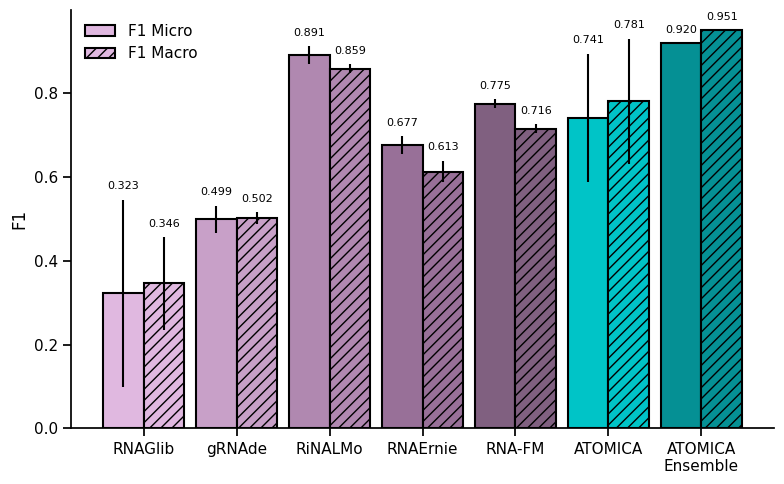

In [77]:
to_plot = pd.concat([
    rnaglib_baselines['RNAGo'],
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    all_metrics,
])
to_plot = to_plot.reset_index()
to_plot.rename(columns={'index': 'model'}, inplace=True)

# Prepare data for grouped bars
n_models = len(to_plot)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = to_plot[('f1_micro', 'mean')].values
f1_micro_stds = to_plot[('f1_micro', 'std')].values
f1_macro_means = to_plot[('f1_macro', 'mean')].values
f1_macro_stds = to_plot[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in to_plot['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/rnago_f1_comparison.svg", format='svg')
plt.show()

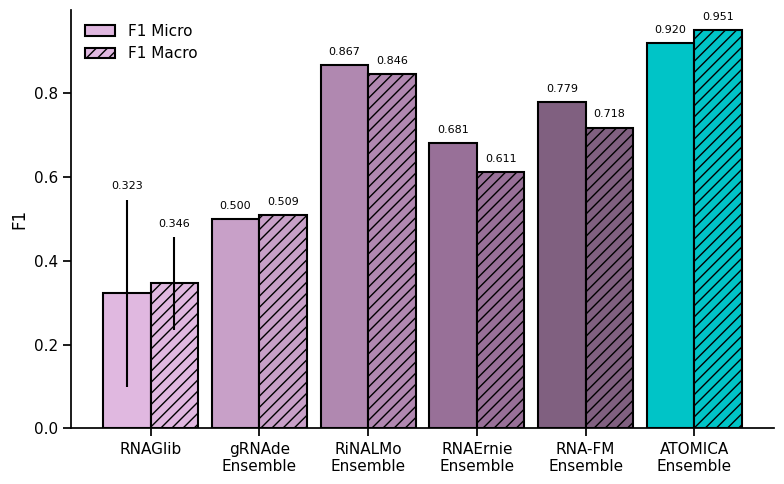

In [78]:
to_plot = pd.concat([
    rnaglib_baselines['RNAGo'],
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    all_metrics[all_metrics.index.str.contains('atomica-ensemble')],
])
to_plot = to_plot.reset_index()
to_plot.rename(columns={'index': 'model'}, inplace=True)

# Prepare data for grouped bars
n_models = len(to_plot)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = to_plot[('f1_micro', 'mean')].values
f1_micro_stds = to_plot[('f1_micro', 'std')].values
f1_macro_means = to_plot[('f1_macro', 'mean')].values
f1_macro_stds = to_plot[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in to_plot['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/rnago_f1_comparison.svg", format='svg')
plt.show()

In [26]:
test_metrics

,checkpoint_path,subset_accuracy,f1_macro,f1_micro,f1_weighted,split
0,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.586667,0.607494,0.672897,0.745256,atomica
1,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.813333,0.745913,0.820000,0.833921,atomica
2,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.626667,0.669947,0.659341,0.631262,atomica
3,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.600000,0.653922,0.635659,0.808953,atomica
4,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.560000,0.675567,0.660194,0.710020,atomica


In [27]:
val_metrics

,checkpoint_path,subset_accuracy,f1_macro,f1_micro,f1_weighted,split
0,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.920000,0.943759,0.950000,0.951977,atomica-val
1,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.920000,0.930507,0.941935,0.942374,atomica-val
2,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.933333,0.900216,0.947368,0.946196,atomica-val
3,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.920000,0.938607,0.960000,0.960095,atomica-val
4,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.880000,0.875113,0.915033,0.915338,atomica-val


# RNA Ligand

In [79]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Ligand", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
 'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
 'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

Test True (44,)
Test Preds (44,)
Test True (44,)
Test Preds (44,)
Test True (44,)
Test Preds (44,)
Test True (44,)
Test Preds (44,)


accuracy           balanced_accuracy            f1_macro  \
                         mean       std              mean       std      mean   
baseline_model                                                                  
grnade               0.659091  0.039365          0.380843  0.064371  0.367019   
rinalmo              0.810606  0.026243          0.882375  0.025556  0.797815   
rnaernie             0.901515  0.112111          0.832567  0.194740  0.801715   
rnafm                0.901515  0.013122          0.942912  0.010925  0.904183   
grnade (ensemble)    0.659091       NaN          0.377011       NaN  0.356108   
rinalmo (ensemble)   0.818182       NaN          0.886207       NaN  0.821381   
rnaernie (ensemble)  0.931818       NaN          0.888506       NaN  0.888506   
rnafm (ensemble)     0.863636       NaN          0.909195       NaN  0.854917   

                               f1_micro           f1_weighted            
                          std      mean       std        mean       std  
baseline_model                                                           
grnade               0.101488  0.659091  0.039365    0.576512  0.057340  
rinalmo              0.035177  0.810606  0.026243    0.819923  0.024574  
rnaernie             0.238956  0.901515  0.112111    0.891819  0.129720  
rnafm                0.014558  0.901515  0.013122    0.906021  0.011833  
grnade (ensemble)         NaN  0.659091       NaN    0.580745       NaN  
rinalmo (ensemble)        NaN  0.818182       NaN    0.829276       NaN  
rnaernie (ensemble)       NaN  0.931818       NaN    0.931818       NaN  
rnafm (ensemble)          NaN  0.863636       NaN    0.870673       NaN

In [45]:
task_name = "RNA_Ligand"
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    label_counts = df['label'].value_counts()
    label_sample_probs = 1/label_counts
    print(split, label_counts, (len(df)-label_counts)/label_counts)

train label
1    137
0     46
2     20
Name: count, dtype: int64 label
1    0.481752
0    3.413043
2    9.150000
Name: count, dtype: float64
val label
1    29
0    10
2     4
Name: count, dtype: int64 label
1    0.482759
0    3.300000
2    9.750000
Name: count, dtype: float64
test label
1    29
0    10
2     5
Name: count, dtype: int64 label
1    0.517241
0    3.400000
2    7.800000
Name: count, dtype: float64


In [95]:
model_checkpoints = [
    f"{SAVED_MODEL_DIR}/RNA_Ligand/version_99/epoch474_step19475.pt",
    f"{SAVED_MODEL_DIR}/RNA_Ligand/version_100/epoch575_step23616.pt",
    f"{SAVED_MODEL_DIR}/RNA_Ligand/version_102/epoch486_step19967.pt",
    f"{SAVED_MODEL_DIR}/RNA_Ligand/version_103/epoch368_step15129.pt",
    f"{SAVED_MODEL_DIR}/RNA_Ligand/version_104/epoch514_step21115.pt",
    # f"{MODEL_DIR}/RNA_Ligand/models/version_98/checkpoint/epoch406_step16687.pt",
#     f"{MODEL_DIR}/RNA_Ligand/models/version_105/checkpoint/epoch395_step16236.pt",
#     f"{MODEL_DIR}/RNA_Ligand/models/version_106/checkpoint/epoch330_step13571.pt",
]

# best checkpoints at < 400 epochs
model_checkpoints = [
 f'{MODEL_DIR}/RNA_Ligand/models/version_109/checkpoint/epoch383_step15744.pt',
 f'{MODEL_DIR}/RNA_Ligand/models/version_117/checkpoint/epoch318_step13079.pt',
 f'{MODEL_DIR}/RNA_Ligand/models/version_108/checkpoint/epoch399_step16400.pt',
 f'{MODEL_DIR}/RNA_Ligand/models/version_118/checkpoint/epoch334_step13735.pt',
 f'{MODEL_DIR}/RNA_Ligand/models/version_120/checkpoint/epoch371_step15252.pt'
]


all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Ligand", split="test", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results['label']),
        y_pred=np.stack(atomica_results['pred']),
        y_proba=np.stack(atomica_results['pred_probability']),
        labels=[0,1,2]
    )
    
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Ligand", split="val", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_pred=np.stack(atomica_results_val['pred']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        labels=[0,1,2]
    )
    # ensemble by mean ##############
    # if ensemble_prob is None:
    #     ensemble_prob = atomica_results['pred_probability']
    # else:
    #     ensemble_prob += atomica_results['pred_probability']
    ##############

    # ensemble by max ##############
    if ensemble_prob is None:
        ensemble_prob = np.stack(atomica_results['pred_probability'])
    else:
        new_prob = np.stack(atomica_results['pred_probability'])
        assert ensemble_prob.shape == new_prob.shape, f"{ensemble_prob.shape} != {new_prob.shape}"
        ensemble_prob = np.stack([ensemble_prob, new_prob], axis=0)
        ensemble_prob = np.max(ensemble_prob, axis=0)
    ##############

    # # ensemble by vote ##############
    # if ensemble_prob is None:
    #     ensemble_prob = np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)
    # else:
    #     ensemble_prob = np.concatenate([ensemble_prob, np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)], axis=1)
    ##############

    metrics_dict = {
        'model': 'atomica-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
    }
    all_metrics.append(metrics_dict)

# ensemble by mean ##############
# ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
##############

# ensemble by max ##############
ensemble_prob = np.stack(ensemble_prob) / np.sum(ensemble_prob, axis=1, keepdims=True)
##############

# ensemble by vote ##############
# ensemble_prob_ = np.zeros((ensemble_prob.shape[0], 3))
# ensemble_prob, ensemble_counts = np.unique(ensemble_prob, axis=1, return_counts=True)
# ensemble_prob_[np.arange(ensemble_prob_.shape[0])[:, None], ensemble_prob] = ensemble_counts
# ensemble_prob = ensemble_prob_ / np.sum(ensemble_prob_, axis=1, keepdims=True)
##############

ensemble_pred = np.argmax(ensemble_prob, axis=1)
ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(atomica_results['label']),
    y_pred=np.stack(ensemble_pred),
    y_proba=np.stack(ensemble_prob),
    labels=[0,1,2]
)

metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': ensemble_metrics.accuracy,
    'balanced_accuracy': ensemble_metrics.balanced_accuracy,
    'f1_macro': ensemble_metrics.f1_macro,
    'f1_micro': ensemble_metrics.f1_micro,
    'f1_weighted': ensemble_metrics.f1_weighted,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)

atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})

# for metric in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_micro', 'f1_weighted']:
#     atomica_metrics.loc['atomica-ensemble', (metric, 'std')] = atomica_metrics.loc['atomica', (metric, 'std')] 

display(atomica_metrics)

accuracy           balanced_accuracy            f1_macro  \
                      mean       std              mean       std      mean   
model                                                                        
atomica           0.850000  0.052322          0.783678  0.115888  0.791221   
atomica-ensemble  0.840909       NaN          0.700000       NaN  0.752957   
atomica-val       0.902326  0.019457          0.773103  0.025490  0.816459   

                            f1_micro           f1_weighted            
                       std      mean       std        mean       std  
model                                                                 
atomica           0.101454  0.850000  0.052322    0.846196  0.058086  
atomica-ensemble       NaN  0.840909       NaN    0.825699       NaN  
atomica-val       0.015121  0.902326  0.019457    0.896458  0.019220

In [47]:
all_metrics[all_metrics['model'] == 'atomica']

,model,checkpoint_path,accuracy,balanced_accuracy,f1_macro,f1_micro,f1_weighted
0,atomica,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.863636,0.843678,0.855556,0.863636,0.858333
2,atomica,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.795455,0.665517,0.692225,0.795455,0.794184
4,atomica,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.909091,0.910345,0.910345,0.909091,0.909091
6,atomica,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.886364,0.843678,0.817821,0.886364,0.891357
8,atomica,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.795455,0.655172,0.680160,0.795455,0.778017


In [48]:
all_metrics[all_metrics['model'] == 'atomica-val']

,model,checkpoint_path,accuracy,balanced_accuracy,f1_macro,f1_micro,f1_weighted
1,atomica-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.930233,0.800000,0.835620,0.930233,0.924339
3,atomica-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.906977,0.788506,0.824321,0.906977,0.901477
5,atomica-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.906977,0.766667,0.819864,0.906977,0.899104
7,atomica-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.883721,0.777011,0.798881,0.883721,0.882940
9,atomica-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.883721,0.733333,0.803610,0.883721,0.874427


/tmp/ipykernel_3662965/2292030264.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],


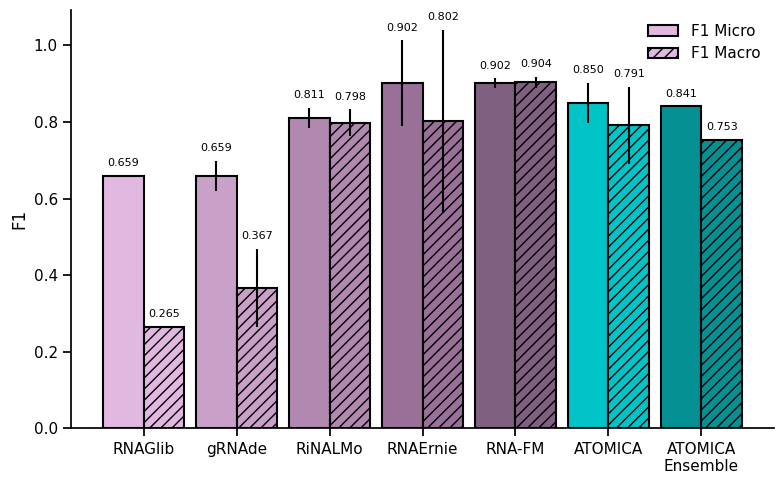

In [53]:
results = pd.concat([
    rnaglib_baselines['RNA_Ligand'],
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics,
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[results['model'] != 'atomica-val']

# Prepare data for grouped bars
n_models = len(results)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = results[('f1_micro', 'mean')].values
f1_micro_stds = results[('f1_micro', 'std')].values
f1_macro_means = results[('f1_macro', 'mean')].values
f1_macro_stds = results[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.savefig(f"{DATA_DIR}/rna_ligand_f1_comparison.svg", format='svg')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3662965/3933333087.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],


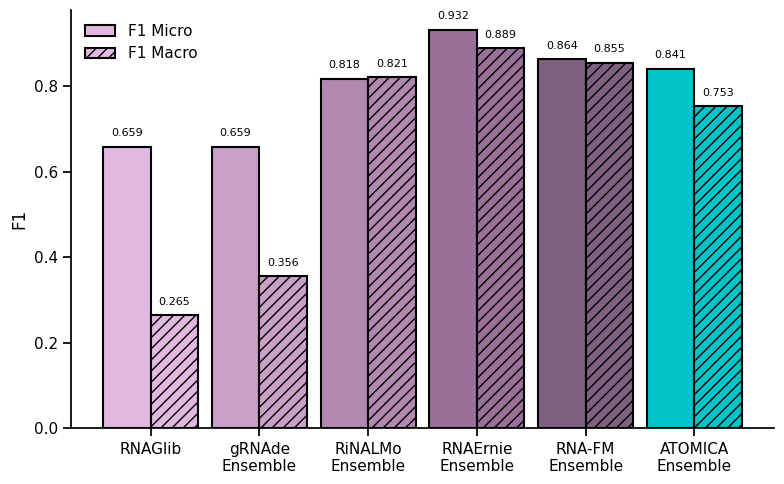

In [55]:
results = pd.concat([
    rnaglib_baselines['RNA_Ligand'],
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[results['model'] != 'atomica-val']

# Prepare data for grouped bars
n_models = len(results)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = results[('f1_micro', 'mean')].values
f1_micro_stds = results[('f1_micro', 'std')].values
f1_macro_means = results[('f1_macro', 'mean')].values
f1_macro_stds = results[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.savefig(f"{DATA_DIR}/rna_ligand_f1_comparison.svg", format='svg')
plt.tight_layout()
plt.show()

# RNA-Protein (SOTA)
This also beats RNAGlib 

In [80]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Protein", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

Test True (10904,)
Test Preds (10904,)
Test True (10904,)
Test Preds (10904,)
Test True (10904,)
Test Preds (10904,)
Test True (10721,)
Test Preds (10721,)


accuracy           balanced_accuracy             roc_auc  \
                         mean       std              mean       std      mean   
baseline_model                                                                  
grnade               0.724590  0.000706          0.502345  0.002230  0.684695   
rinalmo              0.690847  0.005113          0.551548  0.004303  0.629293   
rnaernie             0.707844  0.003394          0.562670  0.009848  0.637649   
rnafm                0.669357  0.011333          0.548803  0.011591  0.616460   
grnade (ensemble)    0.724279       NaN          0.502200       NaN  0.686710   
rinalmo (ensemble)   0.697909       NaN          0.551145       NaN  0.632664   
rnaernie (ensemble)  0.713316       NaN          0.561865       NaN  0.644359   
rnafm (ensemble)     0.673973       NaN          0.548795       NaN  0.622090   

                                  auprc            
                          std      mean       std  
baseline_model                                     
grnade               0.001304  0.485173  0.003355  
rinalmo              0.004043  0.376287  0.002961  
rnaernie             0.002702  0.389490  0.006463  
rnafm                0.001187  0.356953  0.001894  
grnade (ensemble)         NaN  0.487290       NaN  
rinalmo (ensemble)        NaN  0.378431       NaN  
rnaernie (ensemble)       NaN  0.396575       NaN  
rnafm (ensemble)          NaN  0.361190       NaN

In [97]:
model_checkpoints = [
    f"{SAVED_MODEL_DIR}/RNA_Protein/version_1/epoch14_step3210.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein/version_2/epoch12_step2782.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein/version_3/epoch11_step2568.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein/version_4/epoch14_step3210.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein/version_5/epoch19_step4280.pt",
]

model_checkpoints_no_PRNA = [
    f"{SAVED_MODEL_DIR}/RNA_Protein_no_PRNA_in_pretrain/version_6/epoch15_step3440.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein_no_PRNA_in_pretrain/version_7/epoch9_step2140.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein_no_PRNA_in_pretrain/version_8/epoch11_step2604.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein_no_PRNA_in_pretrain/version_9/epoch13_step2982.pt",
    f"{SAVED_MODEL_DIR}/RNA_Protein_no_PRNA_in_pretrain/version_10/epoch13_step3038.pt",
]

# Fixed dataset, no PRNA pretrain
model_checkpoints_no_PRNA = [
    f"{MODEL_DIR}/RNA_Protein/models/version_11/checkpoint/epoch14_step3240.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_12/checkpoint/epoch11_step2592.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_13/checkpoint/epoch13_step2982.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_14/checkpoint/epoch8_step1926.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_15/checkpoint/epoch18_step4123.pt",
]

model_checkpoints = [
    f'{MODEL_DIR}/RNA_Protein/models/version_18/checkpoint/epoch15_step3408.pt',
    f'{MODEL_DIR}/RNA_Protein/models/version_16/checkpoint/epoch12_step2782.pt',
    f'{MODEL_DIR}/RNA_Protein/models/version_17/checkpoint/epoch7_step1728.pt',
    f'{MODEL_DIR}/RNA_Protein/models/version_20/checkpoint/epoch18_step4104.pt',
    f'{MODEL_DIR}/RNA_Protein/models/version_19/checkpoint/epoch7_step1736.pt',
]

all_metrics = []
ensemble_prob = None
ensemble_prob_val = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Protein", split="test")
    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Protein", split="val")
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
        ensemble_prob_val = atomica_results_val['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
        ensemble_prob_val += atomica_results_val['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob_no_PRNA = None
for model_checkpoint in model_checkpoints_no_PRNA:
    atomica_results_no_PRNA = get_atomica_results(model_checkpoint, "RNA_Protein", split="test")
    if ensemble_prob_no_PRNA is None:
        ensemble_prob_no_PRNA = atomica_results_no_PRNA['pred_probability']
    else:
        ensemble_prob_no_PRNA += atomica_results_no_PRNA['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-PRNA',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_no_PRNA['label'] == atomica_results_no_PRNA['pred']),
        'roc_auc': roc_auc_score(atomica_results_no_PRNA['label'], atomica_results_no_PRNA['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_prob_no_PRNA = np.stack(ensemble_prob_no_PRNA) / len(model_checkpoints_no_PRNA)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results_val['label'], (ensemble_prob_val >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = ensemble_prob > best_f1
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

ensemble_pred_no_PRNA = ensemble_prob_no_PRNA > best_f1
precision, recall, thresholds = precision_recall_curve(atomica_results_no_PRNA['label'], ensemble_prob_no_PRNA)
auprc_no_PRNA = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble-no-PRNA',
    'checkpoint_path': 'ensemble-no-PRNA',
    'accuracy': np.mean(atomica_results_no_PRNA['label'] == ensemble_pred_no_PRNA),
    'roc_auc': roc_auc_score(atomica_results_no_PRNA['label'], ensemble_prob_no_PRNA),
    'auprc': auprc_no_PRNA,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

atomica_metrics.loc['atomica-ensemble', ('accuracy', 'std')] = atomica_metrics.loc['atomica', ('accuracy', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('roc_auc', 'std')] = atomica_metrics.loc['atomica', ('roc_auc', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('auprc', 'std')] = atomica_metrics.loc['atomica', ('auprc', 'std')] 
display(atomica_metrics)

Running inference:   1%|          | 1/191 [00:00<02:42,  1.17it/s]


KeyboardInterrupt: 

In [ ]:
len(atomica_results)

10851

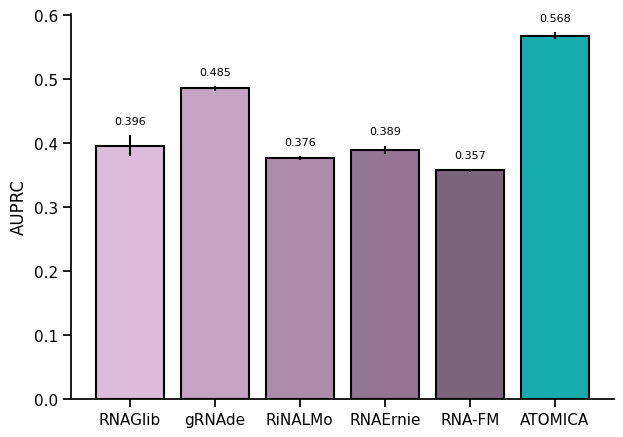

In [84]:
results = pd.concat([
    rnaglib_baselines['RNA_Protein'],
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[~atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('PRNA')) & (~results['model'].str.contains('-val'))]

plt.figure(figsize=(7, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=0
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig(f"{DATA_DIR}/rna_protein_auprc_comparison.svg", format='svg')
plt.show()

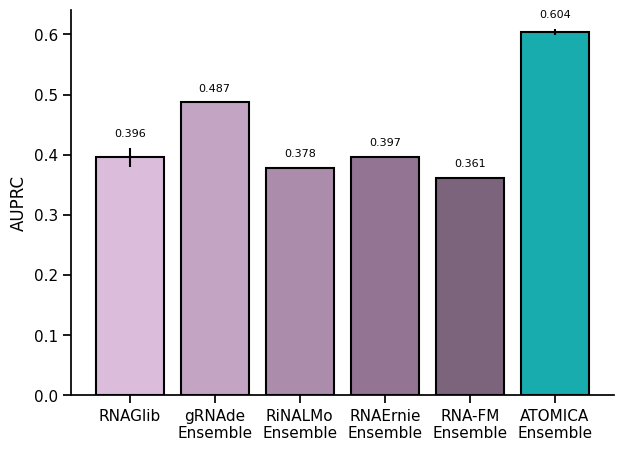

In [85]:
results = pd.concat([
    rnaglib_baselines['RNA_Protein'],
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('PRNA')) & (~results['model'].str.contains('-val'))]

plt.figure(figsize=(7, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=0
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig(f"{DATA_DIR}/rna_protein_auprc_comparison.svg", format='svg')
plt.show()

In [15]:
atomica_metrics

accuracy             roc_auc               auprc  \
                              mean       std      mean       std      mean   
model                                                                        
atomica                   0.749977  0.022051  0.747571  0.007338  0.567653   
atomica-ensemble          0.725924  0.022051  0.774167  0.007338  0.603943   
atomica-ensemble-no-PRNA  0.725924       NaN  0.762443       NaN  0.604166   
atomica-no-PRNA           0.760962  0.019654  0.742432  0.007631  0.561472   

                                    
                               std  
model                               
atomica                   0.005575  
atomica-ensemble          0.005575  
atomica-ensemble-no-PRNA       NaN  
atomica-no-PRNA           0.000000

In [16]:
results

model  accuracy             roc_auc               auprc  \
                         mean       std      mean       std      mean   
0           RNAGlib  0.585343  0.022603  0.670051  0.007817  0.395837   
1            grnade  0.724590  0.000706  0.684695  0.001304  0.485173   
2           rinalmo  0.690847  0.005113  0.629293  0.004043  0.376287   
3          rnaernie  0.707844  0.003394  0.637649  0.002702  0.389490   
4             rnafm  0.669357  0.011333  0.616460  0.001187  0.356953   
5           atomica  0.749977  0.022051  0.747571  0.007338  0.567653   
6  atomica-ensemble  0.725924  0.022051  0.774167  0.007338  0.603943   

                 loss           balanced_accuracy            
        std      mean       std              mean       std  
0  0.016221  0.852408  0.030831               NaN       NaN  
1  0.003355       NaN       NaN          0.502345  0.002230  
2  0.002961       NaN       NaN          0.551548  0.004303  
3  0.006463       NaN       NaN          0.562670  0.009848  
4  0.001894       NaN       NaN          0.548803  0.011591  
5  0.005575       NaN       NaN               NaN       NaN  
6  0.005575       NaN       NaN               NaN       NaN

/tmp/ipykernel_740046/518784302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)
/tmp/ipykernel_740046/518784302.py:6: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)


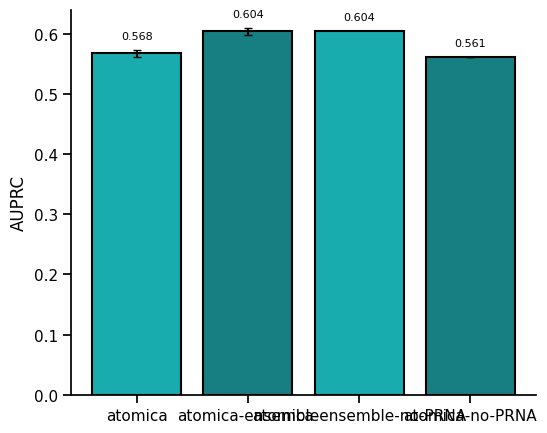

In [17]:
results = atomica_metrics.copy().reset_index()
results.rename(columns={'index': 'model'}, inplace=True)

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=3
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig(f"{DATA_DIR}/rna_protein_f1_comparison.svg", format='svg')
plt.show()

### Grouped scores by id

In [126]:
atomica_results['pred_bin'] = ensemble_pred >= best_t

atomica_results['correct'] = atomica_results['label'] == atomica_results['pred_bin']
balanced_acc = atomica_results.groupby('id')['correct'].mean().mean()

atomica_results['baseline_correct'] = atomica_results['label'] == 0
baseline_acc = atomica_results.groupby('id')['baseline_correct'].mean().mean()

print(balanced_acc, baseline_acc)

0.7491575746522185 0.6970169462442661


In [127]:
grouped = atomica_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.6130
Mean AUROC: 0.5501
Baseline: 0.4230


# RNA-Site (SOTA)




In [ ]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Site", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results

accuracy           balanced_accuracy             roc_auc  \
                    mean       std              mean       std      mean   
baseline_model                                                             
grnade          0.922824  0.000000          0.500000  0.000000  0.569171   
rinalmo         0.922520  0.001412          0.511166  0.003046  0.673028   
rnaernie        0.922828  0.001223          0.508625  0.012465  0.597660   
rnafm           0.921904  0.000000          0.500000  0.000000  0.682820   

                             auprc            
                     std      mean       std  
baseline_model                                
grnade          0.006720  0.111983  0.008234  
rinalmo         0.015329  0.186942  0.020545  
rnaernie        0.018456  0.161948  0.016411  
rnafm           0.012065  0.136566  0.002877

In [86]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Site", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

Test True (2164,)
Test Preds (2164,)
Test True (2164,)
Test Preds (2164,)
Test True (2164,)
Test Preds (2164,)
Test True (2125,)
Test Preds (2125,)


accuracy           balanced_accuracy             roc_auc  \
                         mean       std              mean       std      mean   
baseline_model                                                                  
grnade               0.922824  0.000000          0.500000  0.000000  0.569171   
rinalmo              0.922520  0.001412          0.511166  0.003046  0.673028   
rnaernie             0.922828  0.001223          0.508625  0.012465  0.597660   
rnafm                0.921904  0.000000          0.500000  0.000000  0.682820   
grnade (ensemble)    0.922824       NaN          0.500000       NaN  0.571656   
rinalmo (ensemble)   0.922828       NaN          0.505917       NaN  0.683018   
rnaernie (ensemble)  0.923290       NaN          0.508876       NaN  0.602349   
rnafm (ensemble)     0.921904       NaN          0.500000       NaN  0.692797   

                                  auprc            
                          std      mean       std  
baseline_model                                     
grnade               0.006720  0.111983  0.008234  
rinalmo              0.015329  0.186942  0.020545  
rnaernie             0.018456  0.161948  0.016411  
rnafm                0.012065  0.136566  0.002877  
grnade (ensemble)         NaN  0.109125       NaN  
rinalmo (ensemble)        NaN  0.197251       NaN  
rnaernie (ensemble)       NaN  0.173241       NaN  
rnafm (ensemble)          NaN  0.143167       NaN

In [101]:
# Ensemble five models with the highest validation AUPRC
model_checkpoints = [
    # f"{SAVED_MODEL_DIR}/RNA_Site/version_10/epoch51_step2444.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site/version_28/epoch40_step1927.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site/version_30/epoch67_step3128.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site/version_32/epoch53_step2430.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site/version_33/epoch53_step2592.pt",

    f'{MODEL_DIR}/RNA_Site/models/version_57/checkpoint/epoch55_step2520.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_58/checkpoint/epoch53_step2484.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_60/checkpoint/epoch35_step1620.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_61/checkpoint/epoch52_step2544.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_59/checkpoint/epoch78_step3792.pt',

    # f"{MODEL_DIR}/RNA_Site/models/version_29/checkpoint/epoch67_step3264.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_31/checkpoint/epoch73_step3478.pt",
]

model_checkpoints_no_RNAL = [
    # f"{SAVED_MODEL_DIR}/RNA_Site_no_RNAL_in_pretrain/version_34/epoch76_step3542.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site_no_RNAL_in_pretrain/version_35/epoch62_step2961.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site_no_RNAL_in_pretrain/version_38/epoch46_step2115.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site_no_RNAL_in_pretrain/version_40/epoch73_step3404.pt",
    # f"{SAVED_MODEL_DIR}/RNA_Site_no_RNAL_in_pretrain/version_42/epoch45_step2070.pt",

    f'{MODEL_DIR}/RNA_Site/models/version_53/checkpoint/epoch45_step2116.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_48/checkpoint/epoch38_step1872.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_54/checkpoint/epoch43_step2112.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_50/checkpoint/epoch46_step2115.pt',
    f'{MODEL_DIR}/RNA_Site/models/version_55/checkpoint/epoch29_step1440.pt'

    # f"{MODEL_DIR}/RNA_Site/models/version_37/checkpoint/epoch47_step2304.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_39/checkpoint/epoch63_step3072.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_41/checkpoint/epoch70_step3408.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_43/checkpoint/epoch43_step2112.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_44/checkpoint/epoch67_step3128.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_45/checkpoint/epoch60_step2928.pt",
]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Site", split="test")
    print("Num atomica results", len(atomica_results))
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Site", split="val")
    precision, recall, thresholds = precision_recall_curve(atomica_results_val['label'], atomica_results_val['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_val['label'] == atomica_results_val['pred']),
        'roc_auc': roc_auc_score(atomica_results_val['label'], atomica_results_val['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob_no_RNAL = None
for model_checkpoint in model_checkpoints_no_RNAL:
    atomica_results_no_RNAL = get_atomica_results(model_checkpoint, "RNA_Site", split="test")
    if ensemble_prob_no_RNAL is None:
        ensemble_prob_no_RNAL = atomica_results_no_RNAL['pred_probability']
    else:
        ensemble_prob_no_RNAL += atomica_results_no_RNAL['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results_no_RNAL['label'], atomica_results_no_RNAL['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-RNAL',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_no_RNAL['label'] == atomica_results_no_RNAL['pred']),
        'roc_auc': roc_auc_score(atomica_results_no_RNAL['label'], atomica_results_no_RNAL['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val_no_RNAL = get_atomica_results(model_checkpoint, "RNA_Site", split="val")
    precision, recall, thresholds = precision_recall_curve(atomica_results_val_no_RNAL['label'], atomica_results_val_no_RNAL['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-RNAL-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_val_no_RNAL['label'] == atomica_results_val_no_RNAL['pred']),
        'roc_auc': roc_auc_score(atomica_results_val_no_RNAL['label'], atomica_results_val_no_RNAL['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)


ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_prob_no_RNAL = np.stack(ensemble_prob_no_RNAL) / len(model_checkpoints_no_RNAL)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results['label'], (ensemble_prob >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = (ensemble_prob > best_f1).astype(int)
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

ensemble_pred_no_RNAL = (ensemble_prob_no_RNAL > best_f1).astype(int)
precision, recall, thresholds = precision_recall_curve(atomica_results_no_RNAL['label'], ensemble_prob_no_RNAL)
auprc_no_RNAL = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble-no-RNAL',
    'checkpoint_path': 'ensemble-no-RNAL',
    'accuracy': np.mean(atomica_results_no_RNAL['label'] == ensemble_pred_no_RNAL),
    'roc_auc': roc_auc_score(atomica_results_no_RNAL['label'], ensemble_prob_no_RNAL),
    'auprc': auprc_no_RNAL,
}
all_metrics.append(metrics_dict)


all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

atomica_metrics.loc['atomica-ensemble', ('accuracy', 'std')] = atomica_metrics.loc['atomica', ('accuracy', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('roc_auc', 'std')] = atomica_metrics.loc['atomica', ('roc_auc', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('auprc', 'std')] = atomica_metrics.loc['atomica', ('auprc', 'std')] 
display(atomica_metrics)

Running inference: 100%|██████████| 33/33 [00:10<00:00,  3.28it/s]


Num atomica results 2158


Running inference:   3%|▎         | 1/34 [00:00<00:27,  1.20it/s]


KeyboardInterrupt: 

In [88]:
all_metrics[all_metrics['model'].isin(['atomica-no-RNAL-val'])].reset_index().sort_values(by='auprc', ascending=False)

,index,model,checkpoint_path,accuracy,roc_auc,auprc
0,11,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.738561,0.318011
1,13,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.740316,0.288825
4,19,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.663626,0.265609
3,17,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.726098,0.256016
2,15,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.717336,0.240620


In [89]:
all_metrics[all_metrics['model']=="atomica-no-RNAL"]

,model,checkpoint_path,accuracy,roc_auc,auprc
10,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921687,0.552347,0.130173
12,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921687,0.597852,0.142785
14,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921687,0.611532,0.160826
16,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921687,0.622942,0.178956
18,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921687,0.606124,0.128573


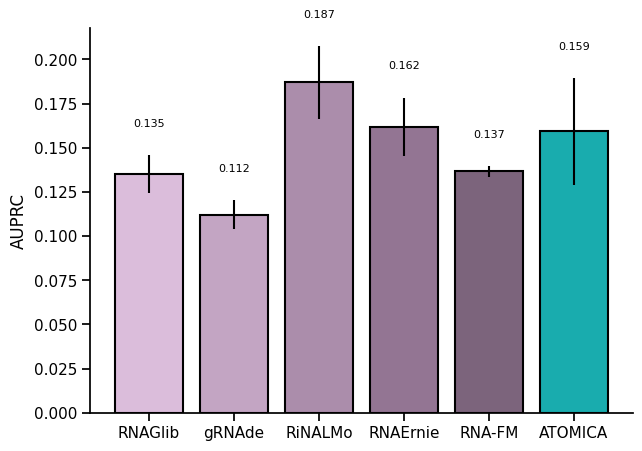

In [91]:
results = pd.concat([
    rnaglib_baselines['RNA_Site'],
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[~atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('RNAL')) & (~results['model'].str.contains('val'))]

plt.figure(figsize=(7, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=0
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig(f"{DATA_DIR}/rna_site_auprc_comparison.svg", format='svg')
plt.show()

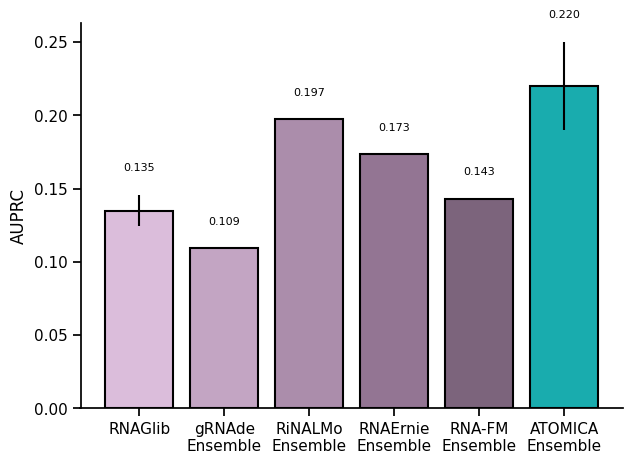

In [92]:
results = pd.concat([
    rnaglib_baselines['RNA_Site'],
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('RNAL')) & (~results['model'].str.contains('val'))]

plt.figure(figsize=(7, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=0
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig(f"{DATA_DIR}/rna_site_auprc_comparison.svg", format='svg')
plt.show()

/tmp/ipykernel_3590174/3138951666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)
/tmp/ipykernel_3590174/3138951666.py:6: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)


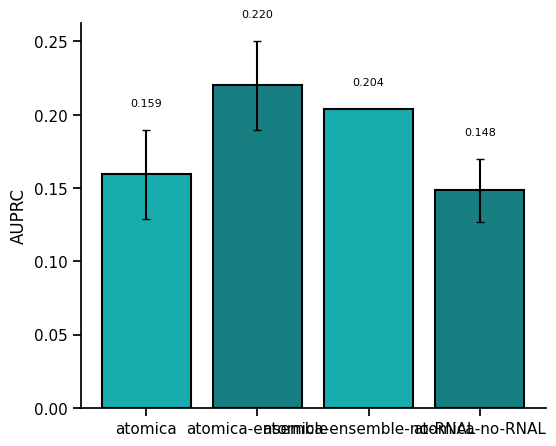

In [20]:
results = atomica_metrics[~atomica_metrics.index.str.contains('val')].copy().reset_index()
results.rename(columns={'index': 'model'}, inplace=True)

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=3
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_positions)
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.show()

### Grouped scores by id

In [95]:
ensemble_results = {
    'id': atomica_results['id'].apply(lambda x: "_".join(x.split('_')[0:2])),
    'pred': ensemble_pred,
    'label': atomica_results['label'],
    'pred_probability': ensemble_prob,
}
ensemble_results = pd.DataFrame(ensemble_results)
grouped = ensemble_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.5071
Mean AUROC: 0.5430
Baseline: 0.1034
